## NLP Project 5: Social Media Comment Analysis

## Problem Statement
A company regularly launches products and marketing campaigns on social media platforms where
customers share comments, opinions, and reactions. Understanding public sentiment and customer
perception is important for brand reputation and business growth. Since social media generates huge
volumes of unstructured text data, the company wants to use NLP techniques to analyze customer
comments, identify trending topics, and understand overall public opinion about its products and
services.

## Tasks
1. Collect social media comments.
2. Clean and preprocess text.
3. Perform sentiment analysis.
4. Identify trending topics.
5. Visualize public opinion.

## Step 1: Import Libraries

In [15]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [16]:
comments = [
    "Amazing product! I love it.",
    "Worst experience ever.",
    "Very good quality.",
    "Delivery was late.",
    "Excellent customer service.",
    "Not worth the money.",
    "Super fast delivery.",
    "The product is okay.",
    "Highly recommended.",
    "Very disappointed.",
    "Beautiful design.",
    "Poor packaging.",
    "Easy to use.",
    "Waste of money.",
    "Fantastic product.",
    "Average performance.",
    "Love this brand.",
    "Bad quality.",
    "Great value for money.",
    "Will buy again."
]

df = pd.DataFrame({"Comment": comments})

df.head()

,Comment
0,Amazing product! I love it.
1,Worst experience ever.
2,Very good quality.
3,Delivery was late.
4,Excellent customer service.


## Step 2: Clean and Preprocess Text

In [17]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Comment"] = df["Comment"].apply(clean_text)

df.head()

,Comment,Cleaned_Comment
0,Amazing product! I love it.,amazing product love
1,Worst experience ever.,worst experience ever
2,Very good quality.,good quality
3,Delivery was late.,delivery late
4,Excellent customer service.,excellent customer service


## Step 4: Perform Sentiment Analysis

In [18]:
sia = SentimentIntensityAnalyzer()

def sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Cleaned_Comment"].apply(sentiment)

df

,Comment,Cleaned_Comment,Sentiment
0,Amazing product! I love it.,amazing product love,Positive
1,Worst experience ever.,worst experience ever,Negative
2,Very good quality.,good quality,Positive
3,Delivery was late.,delivery late,Neutral
4,Excellent customer service.,excellent customer service,Positive
5,Not worth the money.,worth money,Positive
6,Super fast delivery.,super fast delivery,Positive
7,The product is okay.,product okay,Positive
8,Highly recommended.,highly recommended,Positive
9,Very disappointed.,disappointed,Negative


In [19]:
vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["Cleaned_Comment"])

words = vectorizer.get_feature_names_out()

counts = X.sum(axis=0).A1

word_df = pd.DataFrame({
    "Word": words,
    "Count": counts
})

word_df = word_df.sort_values(by="Count", ascending=False)

word_df.head(10)

,Word,Count
25,product,3
20,money,3
7,delivery,2
19,love,2
26,quality,2
0,amazing,1
1,average,1
2,bad,1
3,beautiful,1
5,buy,1


## Step 5: Visualize Public Opinion (Sentiment)

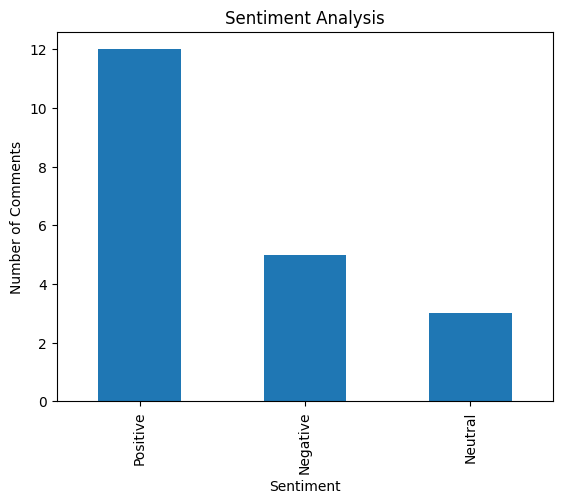

In [20]:
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.show()

## Step 6: Visualize Trending Topics (Word Cloud)

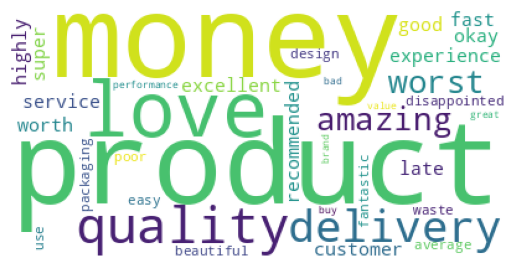

In [21]:
text = " ".join(df["Cleaned_Comment"])

wordcloud = WordCloud(background_color="white").generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [22]:
print(df)

                        Comment             Cleaned_Comment Sentiment
0   Amazing product! I love it.        amazing product love  Positive
1        Worst experience ever.       worst experience ever  Negative
2            Very good quality.                good quality  Positive
3            Delivery was late.               delivery late   Neutral
4   Excellent customer service.  excellent customer service  Positive
5          Not worth the money.                 worth money  Positive
6          Super fast delivery.         super fast delivery  Positive
7          The product is okay.                product okay  Positive
8           Highly recommended.          highly recommended  Positive
9            Very disappointed.                disappointed  Negative
10            Beautiful design.            beautiful design  Positive
11              Poor packaging.              poor packaging  Negative
12                 Easy to use.                    easy use  Positive
13              Wast